In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
from numpy.fft import fft, ifft

In [3]:
N = 4
h = np.array([np.exp(-(j-3)**2 / 2) for j in range(1, 6)])

In [4]:
def pad(x, N):
    out = np.zeros(N, dtype=x.dtype)
    out[:len(x)] = x
    return out

In [35]:
def blur(x):
    h_hat = fft(
        pad(h, len(x)))
    x_hat = fft(x)
    return np.real(ifft(h_hat * x_hat))

In [36]:
def std_basis(N, i):
    e_i = np.zeros(N)
    e_i[i] = 1
    return e_i

In [37]:
M = 10
N = 6
np.concatenate([np.ones(M)[:, np.newaxis] for _ in range(N)], axis=1).shape

(10, 6)

In [38]:
def implicit2explicit(B, N):
    """Return the matrix representation of operator B: R^N -> R^M (in standard bases)."""
    # Call the linear operator B for each standard basis vector and stack across the columns
    return np.concatenate(
        [B(std_basis(N, i))[:, np.newaxis] for i in range(N)],
        axis=1
    )
    

In [39]:

def original_signal():
    # Construct signal vector, x.
    x = np.zeros(N)
    # Indices differ by one from the prompt since we use 0-based indexing instead of 1-based.
    x[9] = 1
    x[12] = -1
    x[49] = 0.3
    x[69] = -0.2
    return x

np.random.seed(0)

N = 100
sigma = 0.02
x_original = original_signal()
y = blur(x_original) + np.random.normal(0, sigma, N)

In [40]:
import matplotlib.pyplot as plt

In [78]:
from pathlib import Path

In [79]:
IMAGE_DIR = Path('/Users/sean/code/study-hard/cvx-opt/latex/hw4/Images')

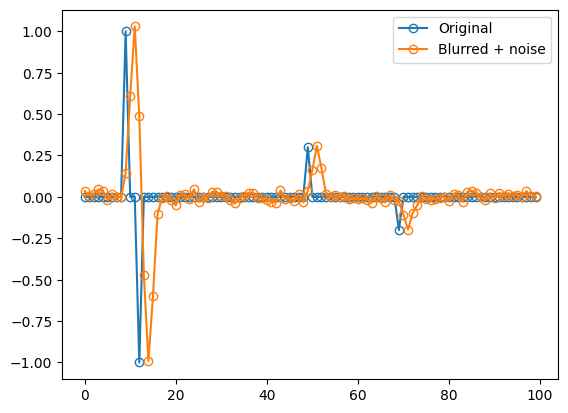

In [80]:
fig = plt.figure()
plt.plot(x_original, '-o', label="Original", fillstyle='none')
plt.plot(y, '-o', label="Blurred + noise", fillstyle='none')
plt.legend()
fig.savefig(IMAGE_DIR / "verify.png")

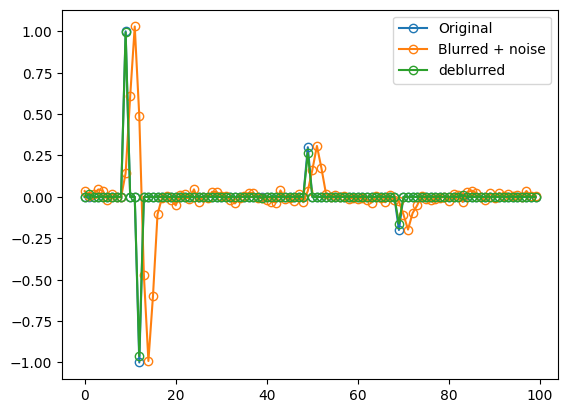

In [81]:
import cvxpy as cp

B_explicit = implicit2explicit(blur, N)
eps = sigma * np.sqrt(N)

x = cp.Variable(N)
objective = cp.Minimize(cp.norm(x, p=1))
constraints = [cp.norm(B_explicit @ x - y, p=2)**2 <= eps**2]
problem = cp.Problem(objective, constraints)
result = problem.solve()

fig = plt.figure()
plt.plot(x_original, '-o', label="Original", fillstyle='none')
plt.plot(y, '-o', label="Blurred + noise", fillstyle='none')
plt.plot(x.value, '-o', label="deblurred", fillstyle='none')
plt.legend()
fig.savefig(IMAGE_DIR / 'deblurred.png')

In [45]:
y.dtype

dtype('float64')

In [46]:
np.imag(y)

array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
       0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.])

In [47]:
# Problem reformulation using dual variable.
x1 = cp.Variable(N)
lambda_ = constraints[0].dual_value
objective_unconstrained = cp.Minimize(
    cp.norm(x1, p=1) + lambda_ * cp.norm(B_explicit @ x1 - y)**2
)
problem1 = cp.Problem(objective_unconstrained)
problem1.solve()
print(np.linalg.norm(x1.value - x.value))



1.2942472780651364e-06


In [ ]:
def H_adjoint(x):
    h_hat = fft(pad(h, len(x)))
    return x * np.conj(h_hat)


def B_adjoint(x):
    return np.real(ifft(H_adjoint(fft(x))))
    

def test_adjoint(A, B, N, M, n_tests=1000):
    # Verify that B is the adjoint of A.
    A_mat = implicit2explicit(A, N)
    B_mat = implicit2explicit(B, M)
    assert A_mat.shape == (M, N), "Matrix representation of  B does not have correct dimensions."
    assert B_mat.shape == (N, M), "Matrix representation of  B does not have correct dimensions."
    for _ in range(n_tests):
        x = np.random.normal(0, 1, N)
        y = np.random.normal(0, 1, M)
        assert np.allclose(
            np.vdot(A_mat @ x, y),
            np.vdot(x, B_mat @ y)
        )
        # print(np.linalg.norm(
        #     np.vdot(A_mat @ x, y) -  np.vdot(x, B_mat @ y)))
            

test_adjoint(blur, B_adjoint, N, N)

In [82]:
from cvx_opt.first_order_methods import lassoSolver

tau = 1 / (2 * lambda_)
x_direct, solver_info = lassoSolver(blur, y, tau, B_adjoint)

print(np.linalg.norm(x_direct - x1.value))

Iter.  Objective Stepsize
-----  --------- --------
    0  2.06e+00  1.42e-01
  162  1.35e-01  1.42e-01
==  Quitting due to stagnating objective value  ==
0.00040458279990506337


In [76]:
# Problem reformulation using dual variable.
x2 = cp.Variable(N)
lambda_ = constraints[0].dual_value
objective_unconstrained = cp.Minimize(
    tau * cp.norm(x2, p=1) + 1/2 * cp.norm(B_explicit @ x2 - y)**2
)
problem1 = cp.Problem(objective_unconstrained)
problem1.solve()
print(np.linalg.norm(x2.value - x_direct))


0.0004045890985510217


In [71]:
type(result[1])

dict

In [72]:
result[1].keys()

dict_keys(['steps', 'fcnHistory', 'errHistory', 'flag', 'fx'])

In [70]:
result[0].dtype

dtype('float64')